МОСКОВСКИЙ ГОСУДАРСТВЕННЫЙ ТЕХНИЧЕСКИЙ УНИВЕРСИТЕТ им. Н.Э. Баумана

Факультет “Информатика и системы управления” Кафедра “Системы обработки информации и управления”

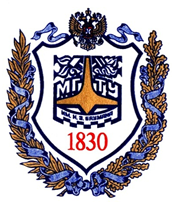

Дисциплина “Системное программирование”

Отчёт по лабораторной работе №2. Вариант №18 “Вывод символов на экран дисплея.”

Выполнил: Студент группы ИУ5-35Б Сергучанов Т.Н. Преподаватель: Аксенова М.В Артамонов Ю.Н.

Москва 2026



# Задание:
1. Разработать программу на языке ассемблера, которая выводит на экран заданную строку S в обратном порядке.

2. Разработать программу на языке ассемблера, в которой заполнить память N заданными символами, вывести их в виде матрицы по M символов в строке и K строк

3. В задании 2 вывести символы в виде треугольника.

4. Разработать программу на языке ассемблера, в которой для заданного числа N найти сумму его цифр и вывести результат на экран.

5. Разработать программу аналогичную заданию 4 на языке программирования C. Провести сравнение размеров исполняемых файлов. Постараться сократить размер исполняемого файла на языке ассемблера и на языке С.

# Код программы пункта 1.

In [ ]:

format ELF64
public _start
section ".data" writeable
    S db "iJEcfjYGYkTaRdjdLixIKVNkM"          '''Моя строка по варианту. Записываем её побайтово в S'''
    endl db 0xA                               '''перенос строки для красивого вывода'''

section ".text" executable
_start:
    mov rsi, S
    add rsi, 25                               '''записываем в rsi указатель на начало S, прибавляем 25 (количество букв в строке), чтобы регистр указывал на конец строки'''

    round:
        mov rax, 1
        mov rdi, 1                            '''цикл вывода: выводим букву на которую указывает rsi, смещаем его левее на 1 байт. Если rsi не равен адресу на начало строки S, запускаем цикл снова'''
        mov rdx, 1
        syscall

        sub rsi, 1
        cmp rsi, S
        jae round

    mov rax, 1
    mov rdi, 1                                 '''вывод переноса строки'''
    mov rsi, endl
    mov rdx, 1
    syscall

    mov rax, 60
    mov rdi, 0
    syscall                                    '''завершение программы'''

# Скриншот работы программы пункта 1:
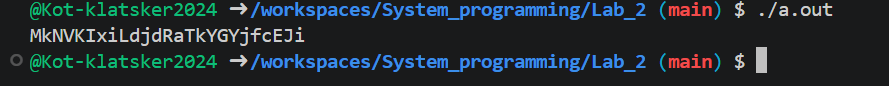

# Код программы пункта 2.

In [ ]:
format ELF64

public _start

section ".data" writeable
    K = 4
    M = 9                               """Записываем количество символов, строк и символов в строке в константы. В виде символа взят $.
                                        Выделяем 1000 байт с запасом для будущей матрицы, но пока не заполняем. Также записываем перенос строки"""
    N = K * M
    char = "$"
    matrix rb 1000
    endl db 0xA

section ".text" executable
_start:
    mov rcx, N                          '''Записываем количество символов в rcx, а rsi указываем на начало матрицы'''
    mov rsi, matrix

record:
    mov byte [rsi], char
    add rsi, 1                          '''цикл record: записываем побайтого символы в матрицу, сдвигам rsi, пока rcx не обнулиться'''
    sub rcx, 1
    cmp rcx, 0
    jne record

    mov rsi, matrix                     '''Возвращаем rsi на начало матрицы и сохраняем в r13 количество строк'''
    mov r13, K

K_loop:
    mov r14, M                          '''сохраняем в r14 количество символов в строке'''

M_loop:
    mov rax, 1                          '''цикл M_loop: выводим в консоль символы в строчку, пока r14 не обнулиться'''
    mov rdi, 1
    mov rdx, 1
    syscall

    add rsi, 1
    sub r14, 1
    cmp r14, 0
    jne M_loop

    mov r12, rsi                        '''После этого выполняется внешний цикл K_loop: выводим перенос строки, после чего снова выполняется внутренний цикл.
                                        Эта цепь разорвётся, когда r13 обнулиться'''

    mov rax, 1
    mov rdi, 1
    mov rsi, endl
    mov rdx, 1
    syscall

    mov rsi, r12

    sub r13, 1
    cmp r13, 0
    jne K_loop

    mov rax, 60
    mov rdi, 0                          '''завершение программы'''
    syscall

# Скриншот работы программы пункта 2:

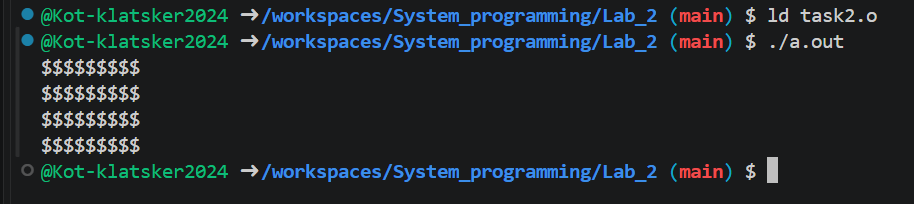

# Код программы пункта 3.

In [ ]:
format ELF64

public _start

section ".data" writeable
    N = 36                        '''N - количество символов из прошлого пункта'''
    char db "$"
    endl db 0xA

section ".text" executable
_start:
    mov r12, N                    '''записываем количество символов в r12'''
    mov r13, 1                    '''r13 хранит количество символов в одной строке. Присваиваем ему 1, так как это вершина пирамиды'''
    mov rsi, char
    loop_str:                     '''цикл для переноса строки'''
        mov rbx, r13              '''записываем в rbx количество символов в текущий момент'''
        loop_$:                   '''цикл для вывода символов'''
            mov rax, 1            '''выводим один символ'''
            mov rdi, 1
            mov rdx, 1
            syscall

            sub r12, 1
            cmp r12, 0           '''уменьшаем счётчик количества символов и, если он равен нулю, значит все символы выведены и срабатывает джампер на завершение программы'''
            je exit_program

            sub rbx, 1           '''если же символы ещё не все выведены, уменьшаем счётчик количества символов в текущей строке и, если он равен нулю,
                                тоесть все символы в данную строчку выведены, переходим во внешний цикл переноса строки'''
            cmp rbx, 0
            jne loop_$

        mov r14, rsi           '''запоминаем адрес символа в r14 чтобы не потерять'''

        mov rax, 1
        mov rdi, 1             '''выводим перенос строки'''
        mov rsi, endl
        mov rdx, 1
        syscall

        mov rsi, r14
        add r13, 1             '''возвращаем адрес символа в rsi, увеличиваем счётчик количества символов в текущей строке и проверяем счётчик общего количества символов.
                                Если он равен нулю, значит все символы выведены и программа завершается'''
        cmp r12, 0
        jne loop_str

    exit_program:
        mov rax, 1
        mov rdi, 1
        mov rsi, endl          '''вывод переноса строки в самом конце для аккуратности'''
        mov rdx, 1
        syscall

        mov rax, 60
        mov rdi, 0             '''завершение программы'''
        syscall

# Скриншот работы программы пункта 3:
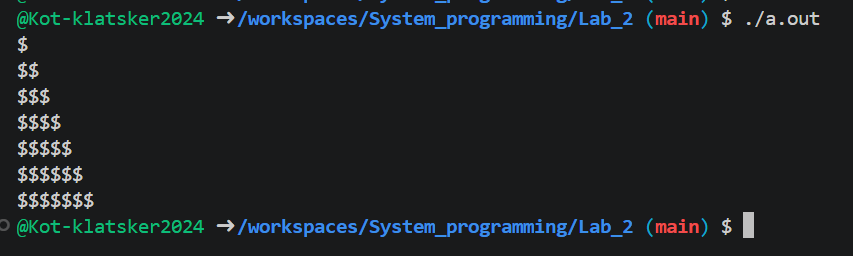

# Код программы пункта 4.

In [ ]:
format ELF64

public _start

section ".data" writeable
    N db "1019734634"            '''число, соответсвующее варианту № 18'''
    result db ?, ?               '''выделили два байта для двухзначного результата'''
    endl   db 0xA

section ".text" executable
_start:
    mov r12, 0                   '''r12 используется для подсчёта суммы. Присвоили r13 адрес хвоста нашего числа, а в rsi вернули адрес на начало. 10 - это количество цифр в числе'''
    mov rsi, N
    add rsi, 10
    mov r13, rsi
    mov rsi, N
                          '''цикл подсчёта суммы: записываем в rax низщего разряда ASCII - код первой цифры числа, смещаем rsi на адрес следующей цифры,
                          вычитаем из него 48 для получения самой цифры, записываем цифру в большой 64 разрядный r14, заполняя свободные ячейки нулями, прибавляем r14 к сумме (r12),
                           далее,если rsi равен r13, то есть хвосту числа, значит все цифры посчитаны и цикл завершается'''
    N_loop:
        mov al, [rsi]
        add rsi, 1
        sub al, 48
        movzx r14, al
        add r12, r14
        cmp rsi, r13
        jne N_loop

    mov eax, r12d
    mov edx, 0            '''записываем сумму в еах и делим его на 10 с помощью есх для получения десятков в еах и единиц в еdx'''
    mov ecx, 10
    div ecx

    add eax, 48           '''зашифровываем десятки и единицы в ASCII - код'''
    add edx, 48

    mov [result], al      '''записываем зашифрованные десятки и единицы в выделенные в начале ячейки памяти'''
    mov [result+1], dl

    mov rax, 1
    mov rdi, 1
    mov rsi, result       '''вывод суммы на экран'''
    mov rdx, 2
    syscall

    mov rax, 1
    mov rdi, 1            '''вывод переноса строки для аккуратности'''
    mov rsi, endl
    mov rdx, 1
    syscall

    mov rax, 60           '''завершение программы'''
    mov rdi, 0
    syscall

# Скриншот калькулятора для проверки:
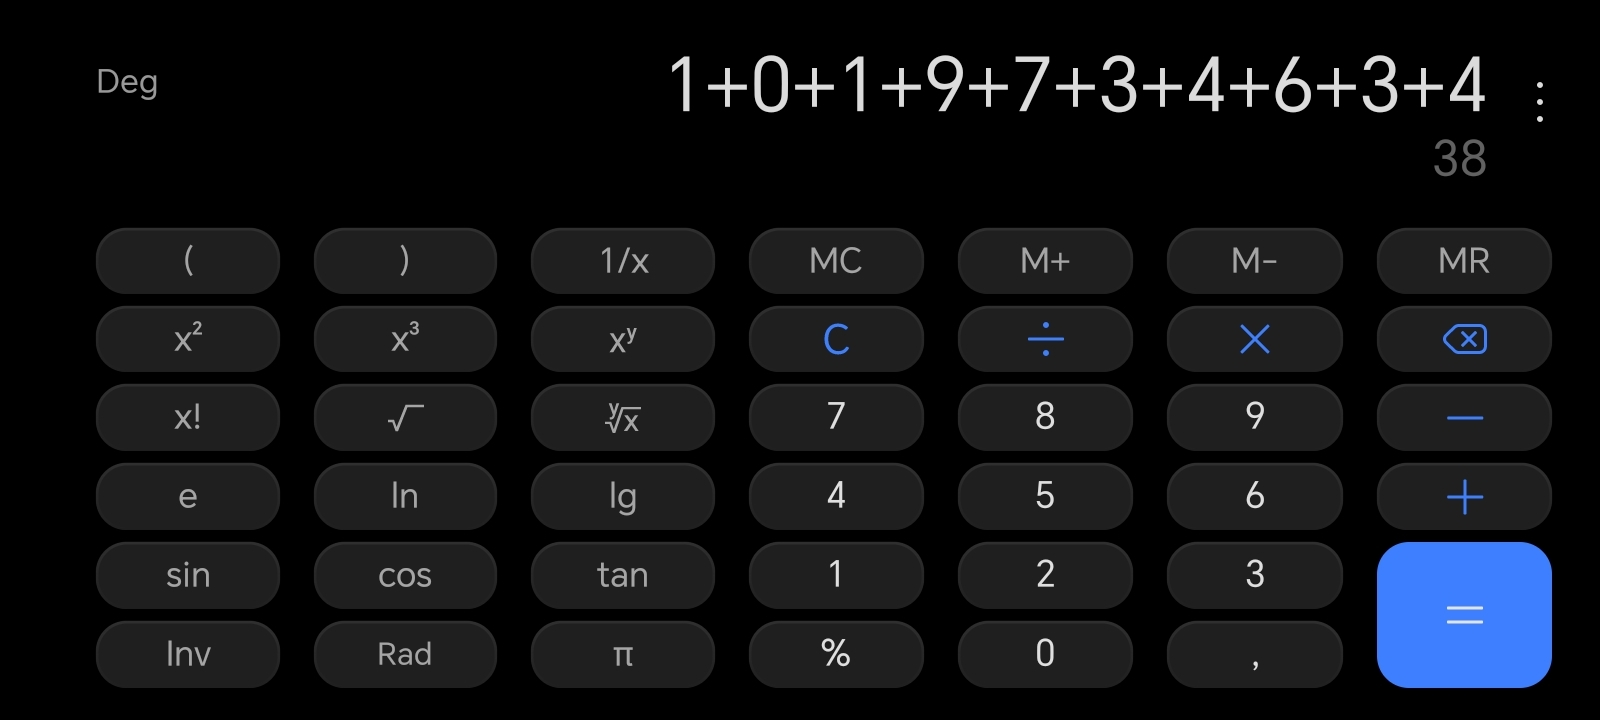

# Скриншот работы программы пункта 4:
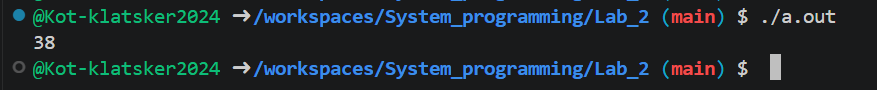

# Код программы пункта 5.

In [ ]:
#include <stdio.h>

int main() {
    char N[] = "1019734634";
    int sum = 0;                     '''счётчик суммы'''

    for (int i = 0; i < 10; i++) {   '''принцип работы цикла: двигаемся по строке от начала до конца, каждую цифру преобразуем в тип int и прибавляем к счётчику суммы'''
        sum += (N[i] - '0');
    }

    printf("%d\n", sum);             '''выводим сумму на экран и завершаем программу'''
    return 0;
}


# Скриншот работы программы на языке С:
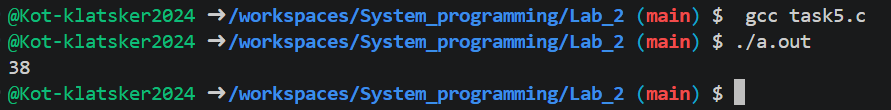

# Сравнение размеров программы на языке ассемблера и на языке С:
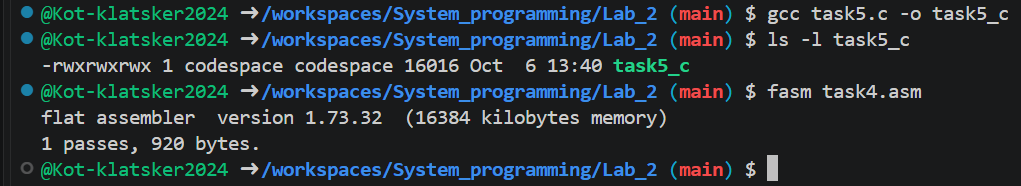

### Программа на С весит 16016 байт, что на 16016-920= 15 096 байт или 14.7 килобайт больше, чем программа на языке ассемблера. Попробуем сократить размер программы и на первом, и на втором языках

# Код облегчённой программы на С.

In [ ]:
'''Самостоятельное определение системного вызова через встроенный ассемблер GCC'''
long syscall(long number, long arg1, long arg2, long arg3) {
    long ret;
      '''Передаем параметры в регистры x86_64, как этого требует ядро Linux'''
    __asm__ volatile (
        "movq %1, %%rax\n\t"  '''Номер системного вызова в RAX'''
        "movq %2, %%rdi\n\t"  '''Дескриптор (stdout) в RDI'''
        "movq %3, %%rsi\n\t"  '''Адрес буфера в RSI'''
        "movq %4, %%rdx\n\t"  '''Длина буфера в RDX'''
        "syscall\n\t"
        "movq %%rax, %0\n\t"  '''Сохраняем результат'''
        : "=r" (ret)
        : "g" (number), "g" (arg1), "g" (arg2), "g" (arg3)
        : "rax", "rdi", "rsi", "rdx", "rcx", "r11", "memory"
    );
    return ret;
}

void _start() {
    char N[] = "1019734634";
    int sum = 0;

    for (int i = 0; i < 10; i++) {
        sum += (N[i] - 48);
    }

    char result[3];
    result[0] = (sum / 10) + 48;
    result[1] = (sum % 10) + 48;
    result[2] = 0xA;

    '''Вызываем наш собственный syscall
      1 — это номер sys_write, 1 — дескриптор stdout'''
    syscall(1, 1, (long)result, 3);

    '''60 — это номер sys_exit, 0 — код возврата'''
    syscall(60, 0, 0, 0);
}


# Код облегчённой программы на языке ассемблера.

In [ ]:
format ELF64

public _start

'''Объединяем код и данные в одну секцию, чтобы сэкономить на заголовках ELF'''
section ".text" executable writeable

    N db "1019734634"
    result db ?, ?
    endl   db 0xA

_start:
    xor r12d, r12d      '''Оптимизация: xor занимает 3 байта вместо 7 байт у mov r12'''
    mov rsi, N
    add rsi, 10
    mov r13, rsi
    mov rsi, N

N_loop:
    mov al, [rsi]
    add rsi, 1
    sub al, 48
    movzx r14, al
    add r12, r14
    cmp rsi, r13
    jne N_loop

    mov eax, r12d
    xor edx, edx        '''Оптимизация: xor edx, edx вместо mov edx'''
    mov ecx, 10
    div ecx

    add eax, 48
    add edx, 48

    mov [result], al
    mov [result+1], dl

    mov rax, 1
    mov rdi, 1
    mov rsi, result
    mov rdx, 2
    syscall

    mov rax, 1
    mov rdi, 1
    mov rsi, endl
    mov rdx, 1
    syscall

    mov rax, 60
    xor edi, edi        '''Оптимизация: xor edi, edi вместо mov rdi'''
    syscall


# Повторное сравнение размеров программы на языке С и на языке ассемблера:
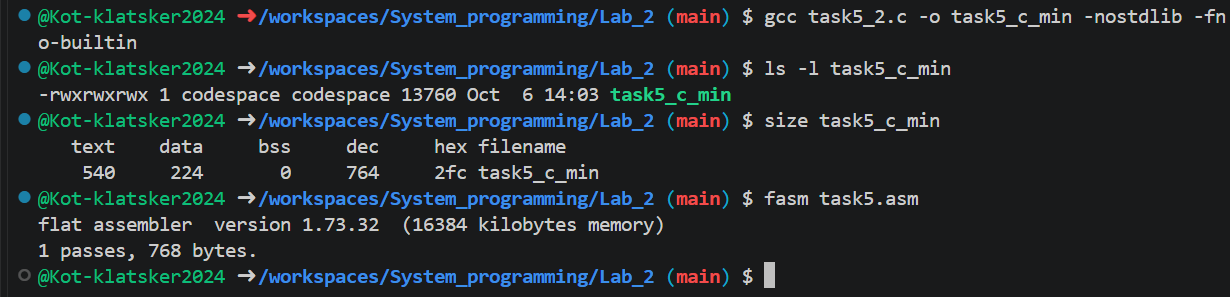

## Программу на ассемблере получилось облегчить на 920-768 = 152 байта, а на языке С 16016 - 13760 = 2256 байт, но разница по-прежнему осталась огромной. Стоит заметить, что сам код на С весит всего 540 байт, а это значит, что всё остальное это проделки компилятора gcc